# SED Poisson Workflow

This notebook reproduces the per-bin SED Poisson workflow and validates the Poisson approximation against direct log-likelihood evaluation.

In [55]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

%run ../pylib/tools dark
from importlib import reload
from astropy.coordinates import SkyCoord
from like3 import pixel_table as pixel_table_mod; reload(pixel_table_mod)
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
from like3 import sedfuns as sedfuns_mod; reload(sedfuns_mod)
from like3 import main as main_mod; reload(main_mod)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PixelTable = pixel_table_mod.PixelTable
SourceModel = sourcelist_mod.SourceModel
FermiFit = main_mod.FermiFit

In [56]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog(
    'v40',
    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)
selected_name = roi_sources.source_names[0]
pt = PixelTable('../files/kerr/toby_v4.fits', source_model=roi_sources, psf_path='../files/loc')
# Running this notebook from docs/ requires an explicit PSF table path.
ff = FermiFit(pt)
selected_name

Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries
Loaded pixel table from "../files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from '../files/loc'


np.str_('FL16Y J0633.9+1746')

In [58]:
sedp = ff.get_sed_poisson_table(source_name=selected_name, tol=0.1)
display(sedp[['elow', 'ehigh', 'flux', 'lflux', 'uflux', 'ts', 'maxdev']].round(1))

,elow,ehigh,flux,lflux,uflux,ts,maxdev
energy,,,,,,,
133,100.0,177.8,225.6,224.7,226.5,236942.9,0.0
237,177.8,316.2,356.7,356.0,357.3,1299103.5,0.0
421,316.2,562.3,534.0,532.8,535.2,781244.3,0.0
749,562.3,1000.0,736.1,734.4,737.8,803658.6,0.0
1333,1000.0,1778.3,843.9,842.0,845.7,821754.0,0.0
2371,1778.3,3162.3,828.0,826.5,829.4,1455115.5,0.0
4216,3162.3,5623.4,578.0,575.4,580.5,211003.2,0.0
7498,5623.4,10000.0,259.3,257.1,261.6,202474.2,0.0
13335,10000.0,17782.8,69.7,68.2,71.3,10986.0,0.0


PASS: plot_sed_with_band_points accepted explicit sed_table.


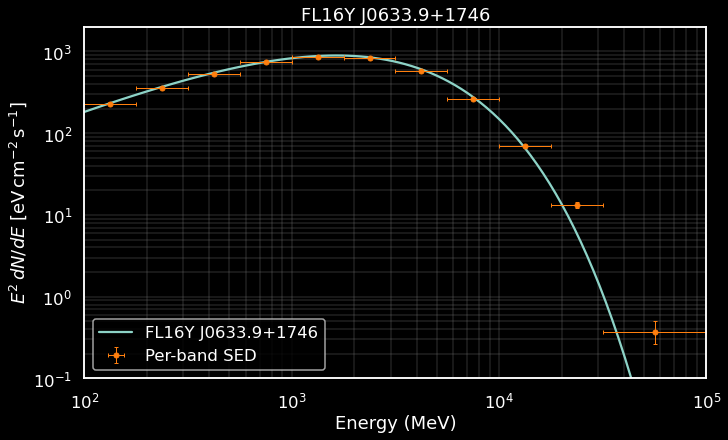

In [60]:
# Verify: plot_sed_with_band_points accepts a precomputed sed_table
src = ff.source_model.find_source(selected_name)
ax2 = ff.plot_sed_with_band_points(src, sed_table=sedp, update=False, tol=0.2)
assert ax2 is not None, 'Expected a matplotlib Axes return value when sed_table is provided.'
print('PASS: plot_sed_with_band_points accepted explicit sed_table.')
ax2.set(ylim=(0.1,2e3))
plt.show()

PASS: plot_sed_with_band_points produced model curve + per-band points.


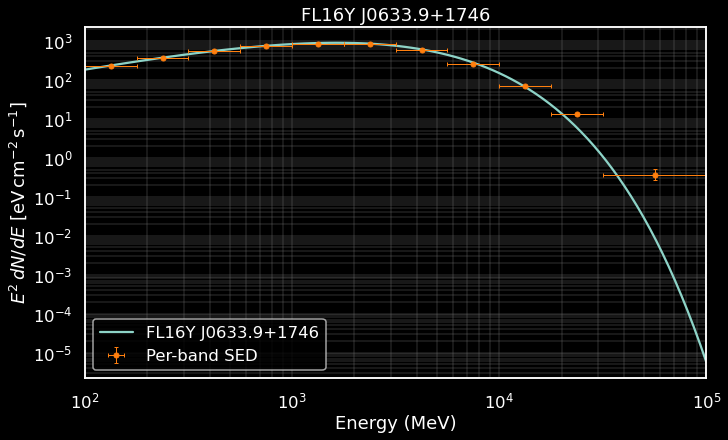

In [53]:
# Test: FermiFit.plot_sed_with_band_points
src = ff.source_model.find_source(selected_name)
ax = ff.plot_sed_with_band_points(src, update=True, tol=0.2)

# Basic API/plot-content checks
assert ax is not None, 'Expected a matplotlib Axes return value.'
assert hasattr(src, 'sed_poisson_table') and src.sed_poisson_table is not None, \
    'Expected source.sed_poisson_table to be available after plotting.'

markers = [line.get_marker() for line in ax.lines]
has_model_line = any(m in (None, 'None', '') for m in markers)
has_band_markers = any(m == 'o' for m in markers)

assert has_model_line, 'Expected a model SED curve line on the axes.'
assert has_band_markers, 'Expected per-band errorbar markers on the axes.'

print('PASS: plot_sed_with_band_points produced model curve + per-band points.')

In [57]:
# Test: FermiFit.sed_poisson_delta_decomposition
src = ff.source_model.find_source(selected_name)
out = ff.sed_poisson_delta_decomposition(src, alpha=1.05, update=True, tol=0.2)

# Structural checks
required = {'per_band', 'sum_poisson_delta', 'all_band_delta', 'difference', 'alpha', 'source_name'}
assert required.issubset(out.keys()), f"Missing keys: {sorted(required - set(out.keys()))}"

per_band = out['per_band']
assert isinstance(per_band, pd.DataFrame), 'Expected per_band to be a pandas DataFrame.'
assert len(per_band) > 0, 'Expected at least one per-band entry.'
assert {'energy', 'flux_ref', 'flux_test', 'dll_poiss'}.issubset(per_band.columns), 'Missing per_band columns.'

# Numeric checks
assert np.isfinite(float(out['sum_poisson_delta'])), 'sum_poisson_delta must be finite.'
assert np.isfinite(float(out['all_band_delta'])), 'all_band_delta must be finite.'
assert np.isfinite(float(out['difference'])), 'difference must be finite.'
assert np.isclose(float(out['alpha']), 1.05), 'alpha mismatch.'
assert out['source_name'] == src.name, 'source_name mismatch.'

print('PASS: sed_poisson_delta_decomposition returned expected structure and finite values.')

PASS: sed_poisson_delta_decomposition returned expected structure and finite values.


In [59]:
# Test: explicit sed_table path for FermiFit.sed_poisson_delta_decomposition
src = ff.source_model.find_source(selected_name)
out2 = ff.sed_poisson_delta_decomposition(src, sed_table=sedp, alpha=1.05, update=False, tol=0.2)
assert np.isfinite(float(out2['sum_poisson_delta'])), 'sum_poisson_delta must be finite.'
assert np.isfinite(float(out2['all_band_delta'])), 'all_band_delta must be finite.'
assert np.isfinite(float(out2['difference'])), 'difference must be finite.'
print('PASS: sed_poisson_delta_decomposition accepted explicit sed_table.')

PASS: sed_poisson_delta_decomposition accepted explicit sed_table.
